In [2]:
import pandas as pd

# Load the raw data
df = pd.read_csv(r"C:\Users\Yashwanth\Downloads\Telco-Customer-Churn.csv")

# First look
print(df.shape)        # rows and columns
print(df.head())       # first 5 rows
print(df.dtypes)       # column data types

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# Check how many blank/space values are in TotalCharges
print(df['TotalCharges'].value_counts().head(10))

# Check exact count of blank spaces
blank = df[df['TotalCharges'].str.strip() == '']
print(f"\nBlank rows: {len(blank)}")

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

Blank rows: 11


In [4]:
# Replace blank spaces with 0 and convert to float
df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = df['TotalCharges'].replace('', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Confirm it's fixed
print(df['TotalCharges'].dtype)   # should show float64
print(df['TotalCharges'].isnull().sum())  # should show 0

float64
0


In [4]:
# Convert 0/1 to Yes/No to match all other columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Confirm
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [5]:
# Add ChurnFlag column (1 = churned, 0 = stayed)
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm
print(df['ChurnFlag'].value_counts())

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64


In [6]:
# Group tenure into buckets for segment analysis
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Confirm
print(df['TenureGroup'].value_counts())

TenureGroup
49+ months      2239
0-12 months     2186
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64


In [7]:
# Full summary check
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())

# Save clean file
df.to_csv(r"C:\Users\Yashwanth\Downloads\Telco_Churn_Clean.csv", index=False)

print("\nClean file saved successfully!")

Shape: (7043, 23)

Null values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ChurnFlag           0
TenureGroup         0
dtype: int64

Clean file saved successfully!


In [8]:
# Rename columns to snake_case and save again
df.columns = [
    'customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
    'tenure', 'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
    'payment_method', 'monthly_charges', 'total_charges', 'churn',
    'churn_flag', 'tenure_group'
]

df.to_csv(r"C:\Users\Yashwanth\Downloads\Telco_Churn_Clean.csv", index=False)
print("Saved with snake_case columns!")

Saved with snake_case columns!


In [9]:
# Check the problem
print(df['total_charges'].value_counts().head(10))
print(df['total_charges'].isnull().sum())

total_charges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64
0


In [10]:
# Strip spaces and replace with 0
df['total_charges'] = df['total_charges'].astype(str).str.strip()
df['total_charges'] = df['total_charges'].replace('', '0')
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce').fillna(0)

# Confirm - should show no blank spaces
print(df['total_charges'].dtype)
print(df['total_charges'].isnull().sum())
print(df[df['total_charges'] == 0])  # should show 11 rows with 0

float64
0
     customer_id  gender senior_citizen partner dependents  tenure  \
488   4472-LVYGI  Female             No     Yes        Yes       0   
753   3115-CZMZD    Male             No      No        Yes       0   
936   5709-LVOEQ  Female             No     Yes        Yes       0   
1082  4367-NUYAO    Male             No     Yes        Yes       0   
1340  1371-DWPAZ  Female             No     Yes        Yes       0   
3331  7644-OMVMY    Male             No     Yes        Yes       0   
3826  3213-VVOLG    Male             No     Yes        Yes       0   
4380  2520-SGTTA  Female             No     Yes        Yes       0   
5218  2923-ARZLG    Male             No     Yes        Yes       0   
6670  4075-WKNIU  Female             No     Yes        Yes       0   
6754  2775-SEFEE    Male             No      No        Yes       0   

     phone_service    multiple_lines internet_service      online_security  \
488             No  No phone service              DSL                  

In [11]:
# Check rows where total_charges is 0
print(df[df['total_charges'] == 0][['customer_id', 'tenure', 'total_charges']])

     customer_id  tenure  total_charges
488   4472-LVYGI       0            0.0
753   3115-CZMZD       0            0.0
936   5709-LVOEQ       0            0.0
1082  4367-NUYAO       0            0.0
1340  1371-DWPAZ       0            0.0
3331  7644-OMVMY       0            0.0
3826  3213-VVOLG       0            0.0
4380  2520-SGTTA       0            0.0
5218  2923-ARZLG       0            0.0
6670  4075-WKNIU       0            0.0
6754  2775-SEFEE       0            0.0


In [12]:
df.to_csv(r"C:\Users\Yashwanth\Downloads\Telco_Churn_Clean.csv", index=False)
print("Saved successfully!")

Saved successfully!


## Charts


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv(r"C:\Users\Yashwanth\Downloads\Telco_Churn_Clean.csv")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded!")
print(df.shape)

Libraries loaded!
(7043, 23)


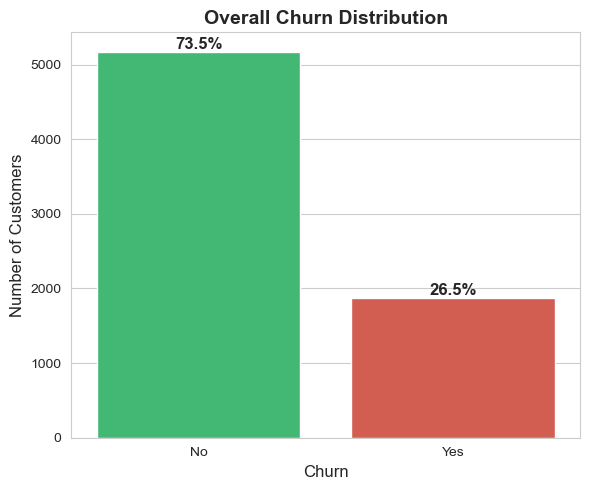

Chart 1 saved!


In [15]:
# Chart 1 - Overall Churn Distribution (updated)
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='churn', hue='churn', 
                   palette=['#2ecc71', '#e74c3c'], legend=False)

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Overall Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\Yashwanth\Downloads\chart1_churn_distribution.png", dpi=150)
plt.show()
print("Chart 1 saved!")

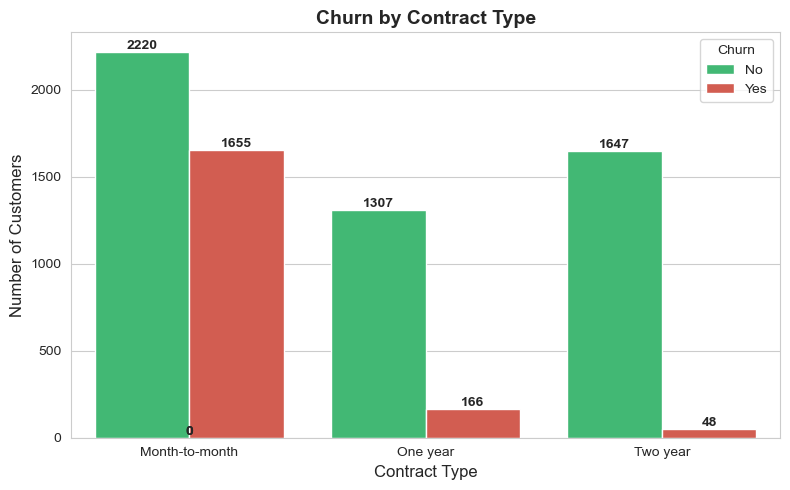

Chart 2 saved!


In [16]:
# Chart 2 - Churn by Contract Type
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='contract', hue='churn',
                   palette=['#2ecc71', '#e74c3c'], legend=True)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig(r"C:\Users\Yashwanth\Downloads\chart2_churn_by_contract.png", dpi=150)
plt.show()
print("Chart 2 saved!")

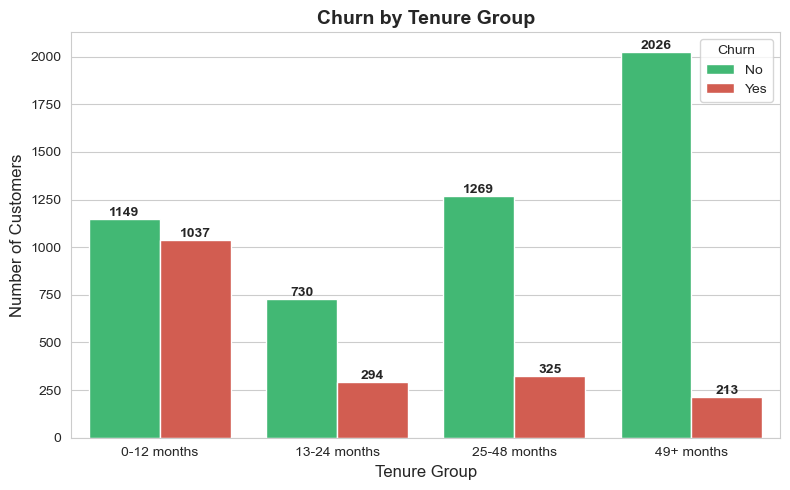

Chart 3 saved!


In [17]:
# Chart 3 - Churn by Tenure Group
plt.figure(figsize=(8, 5))

# Define correct order
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49+ months']

ax = sns.countplot(data=df, x='tenure_group', hue='churn',
                   palette=['#2ecc71', '#e74c3c'], 
                   order=tenure_order, legend=True)

# Add value labels on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Churn by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig(r"C:\Users\Yashwanth\Downloads\chart3_churn_by_tenure.png", dpi=150)
plt.show()
print("Chart 3 saved!")

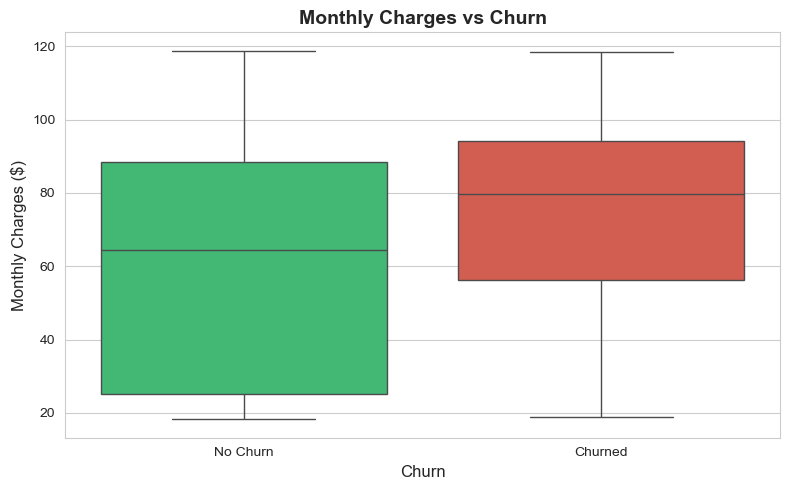

Chart 4 saved!


In [18]:
# Chart 4 - Monthly Charges Distribution by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='monthly_charges',
            hue='churn', palette=['#2ecc71', '#e74c3c'], legend=False)

plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.xticks([0, 1], ['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig(r"C:\Users\Yashwanth\Downloads\chart4_monthly_charges.png", dpi=150)
plt.show()
print("Chart 4 saved!")